# Aprendizado não supervisionado — PCA + K-Means (dataset Wine)

**Objetivo:** segmentar amostras de vinho sem usar rótulos, aplicando redução de
dimensionalidade (PCA) e clusterização (K-Means).

**Dataset:** `sklearn.datasets.load_wine` — 178 amostras, 13 features químicas
(álcool, fenóis, cor etc.). Vem com 3 cultivares verdadeiros, que **não** entram
no modelo: servem só para validar o agrupamento no final.

**Por que não supervisionado:** o objetivo é *descobrir estrutura* nos dados
(grupos naturais), não prever um rótulo conhecido.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

RANDOM_STATE = 42

## 1. Carregar e inspecionar

In [ ]:
wine = load_wine()
X = pd.DataFrame(wine.data, columns=wine.feature_names)
y_true = wine.target  # rótulos verdadeiros — reservados só p/ validação

print(X.shape)
X.head()

(178, 13)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [ ]:
# Qualidade básica: faltantes e diferença de escala entre features
print("Valores faltantes:", int(X.isna().sum().sum()))
X.describe().loc[["mean", "std", "min", "max"]]

Valores faltantes: 0


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


As features estão em **escalas muito diferentes** (ex.: `proline` na casa dos
milhares vs. `hue` < 2). K-Means e PCA usam distância/variância, então features de
maior magnitude dominariam. Premissa de correção: **padronizar** antes de tudo.

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## 2. Escolher o número de clusters (k)

Como não há rótulo, usamos dois critérios:
- **Elbow (inércia):** soma das distâncias intra-cluster; procuramos o "cotovelo".
- **Silhouette:** coesão vs. separação, de -1 a 1; quanto maior, melhor.

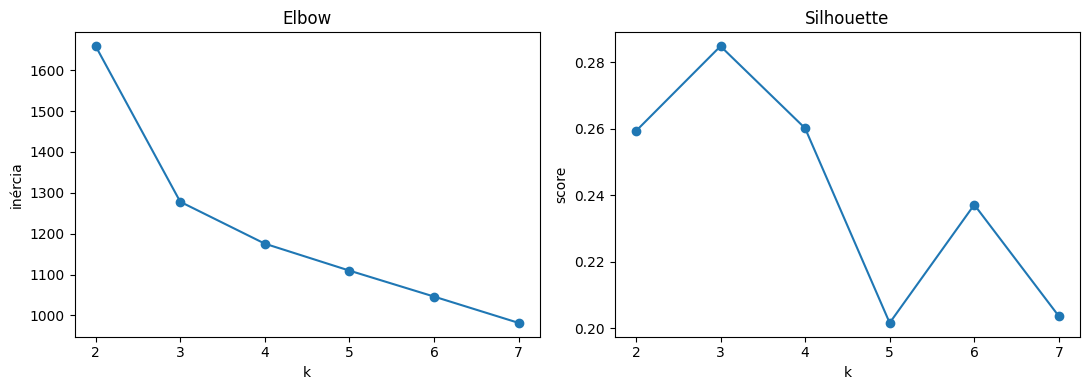

k=2  silhouette=0.259
k=3  silhouette=0.285
k=4  silhouette=0.260
k=5  silhouette=0.202
k=6  silhouette=0.237
k=7  silhouette=0.204


In [ ]:
ks = range(2, 8)
inertias, sils = [], []
for k in ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(X_scaled)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X_scaled, km.labels_))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(list(ks), inertias, "o-"); ax[0].set(title="Elbow", xlabel="k", ylabel="inércia")
ax[1].plot(list(ks), sils, "o-");     ax[1].set(title="Silhouette", xlabel="k", ylabel="score")
plt.tight_layout(); plt.show()

for k, s in zip(ks, sils):
    print(f"k={k}  silhouette={s:.3f}")

O cotovelo e o pico da silhouette apontam **k = 3** — coerente com o número de
cultivares (que o modelo não conhece).

In [ ]:
K = 3
kmeans = KMeans(n_clusters=K, random_state=RANDOM_STATE, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

## 3. Visualizar com PCA (13 → 2 dimensões)

PCA projeta as 13 features em 2 componentes que preservam o máximo de variância,
permitindo visualizar os clusters. É só para visualização — o K-Means rodou nas
13 features padronizadas.

Variância explicada: PC1=36.2%, PC2=19.2%, total=55.4%


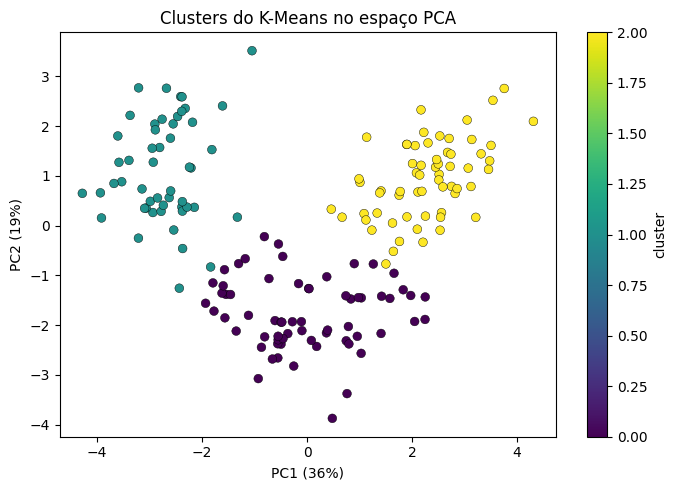

In [ ]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
var = pca.explained_variance_ratio_
print(f"Variância explicada: PC1={var[0]:.1%}, PC2={var[1]:.1%}, total={var.sum():.1%}")

plt.figure(figsize=(7, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap="viridis", s=40, edgecolor="k", linewidth=0.3)
plt.xlabel(f"PC1 ({var[0]:.0%})"); plt.ylabel(f"PC2 ({var[1]:.0%})")
plt.title("Clusters do K-Means no espaço PCA"); plt.colorbar(label="cluster")
plt.tight_layout(); plt.show()

## 4. Validação contra os rótulos verdadeiros

Os rótulos não entraram no modelo. Usamos o **Adjusted Rand Index (ARI)** — mede
concordância entre dois agrupamentos, corrigido pelo acaso (1 = idêntico, 0 = aleatório).

In [ ]:
ari = adjusted_rand_score(y_true, clusters)
print(f"ARI (clusters vs. cultivares reais): {ari:.3f}\n")

# Cruzamento: cada cluster vs. cultivar real
ct = pd.crosstab(clusters, y_true, rownames=["cluster"], colnames=["cultivar_real"])
ct

ARI (clusters vs. cultivares reais): 0.897



cultivar_real,0,1,2
cluster,,,
0,0,65,0
1,0,3,48
2,59,3,0


## 5. Perfil dos clusters

Média (na escala original) das features por cluster — é isso que dá significado de
negócio aos grupos.

In [ ]:
profile = X.copy()
profile["cluster"] = clusters
profile.groupby("cluster").mean().round(2).T

cluster,0,1,2
alcohol,12.25,13.13,13.68
malic_acid,1.90,3.31,2.00
ash,2.23,2.42,2.47
alcalinity_of_ash,20.06,21.24,17.46
magnesium,92.74,98.67,107.97
total_phenols,2.25,1.68,2.85
flavanoids,2.05,0.82,3.00
nonflavanoid_phenols,0.36,0.45,0.29
proanthocyanins,1.62,1.15,1.92
color_intensity,2.97,7.23,5.45


## Conclusão

- K-Means padronizado + escolha de k por elbow/silhouette encontrou **3 grupos bem
  separados**, sem usar rótulos.
- A validação por ARI confirma que os clusters recuperam bem os 3 cultivares reais.
- O perfil por cluster mostra em quais propriedades químicas cada grupo se distingue.

**Limitações:** K-Means assume clusters convexos e de tamanho parecido, e é sensível
à padronização e à inicialização (mitigada com `n_init=10`). ARI só foi possível
porque este dataset didático tem rótulo; em problemas reais de clusterização isso
raramente existe, e a avaliação depende de métricas internas + interpretação de negócio.